In [1]:
1+1

2

In [ ]:
import math

class Value:
    def __init__(self, data, _children=(), _op = '', label='') -> None:
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None
        self.grad = 0

    def __repr__(self) -> str:
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), 'add')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        
        out._backward = _backward
        return out


    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), 'multiply')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self*other


    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = math.tanh(x)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward


        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v: Value):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [105]:
a = Value(3.142, label='a')
b = a.tanh(); b.label = 'b'
b.grad = 1.0

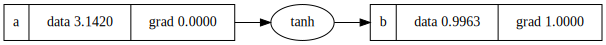

In [106]:
draw_dot(b)

In [107]:
b._backward()

Hey


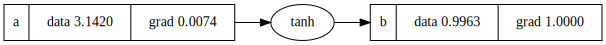

In [108]:
draw_dot(b)

In [104]:
1 - math.tanh(3.1420)**2

0.0074359122829661395

In [2]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
d

Value(data=4.0)

In [3]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [4]:
d._op

'add'

In [27]:
from graphviz import Digraph

In [28]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)           
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid+n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot



In [13]:
nodes, edges = trace(d)
nodes

{Value(data=-3.0),
 Value(data=-6.0),
 Value(data=10.0),
 Value(data=2.0),
 Value(data=4.0)}

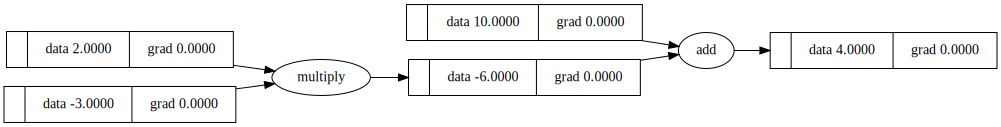

In [14]:
draw_dot(d)

In [15]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
l = d * f; l.label='l'
l 

Value(data=-8.0)

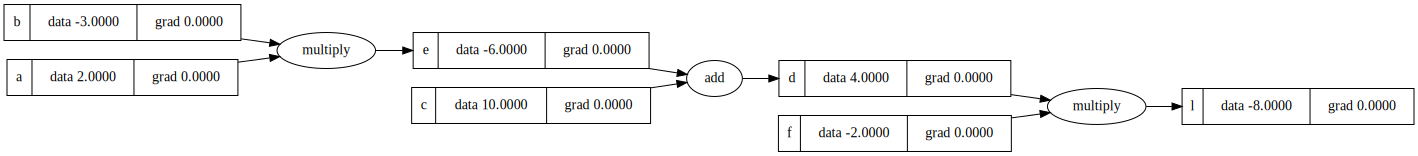

In [16]:
draw_dot(l)

In [17]:
c.grad = -2.0

In [18]:
e.grad = -2.0

In [19]:
a.grad = 6.0
b.grad = -4.0

d.grad = -2.0
f.grad = 4.0

l.grad = 1

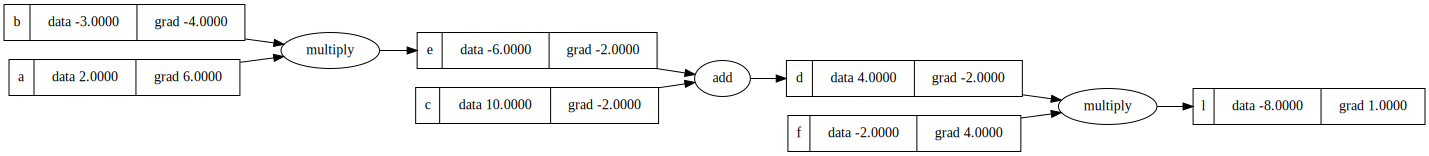

In [20]:
draw_dot(l)

In [ ]:
# inputs x1,x2

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias
b = Value(6.88137358870195432, label='b')
x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2 +b; n.label='n'
o = n.tanh(); o.label='o'

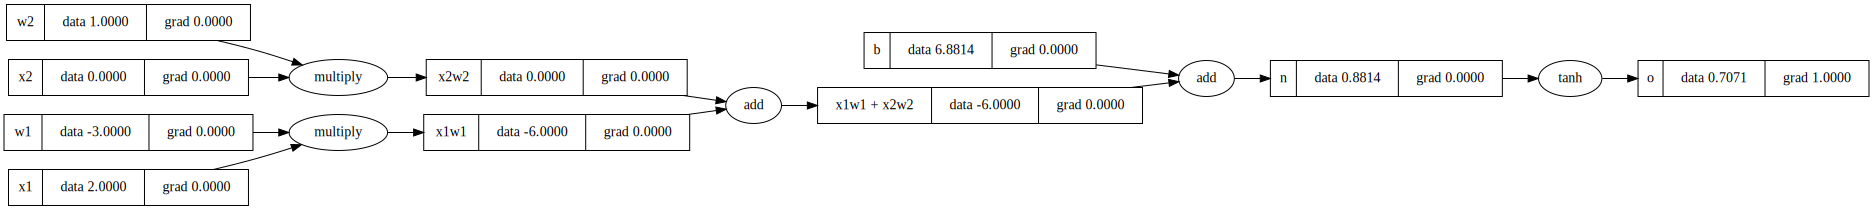

In [127]:
draw_dot(o)

In [111]:
o._backward()

Hey


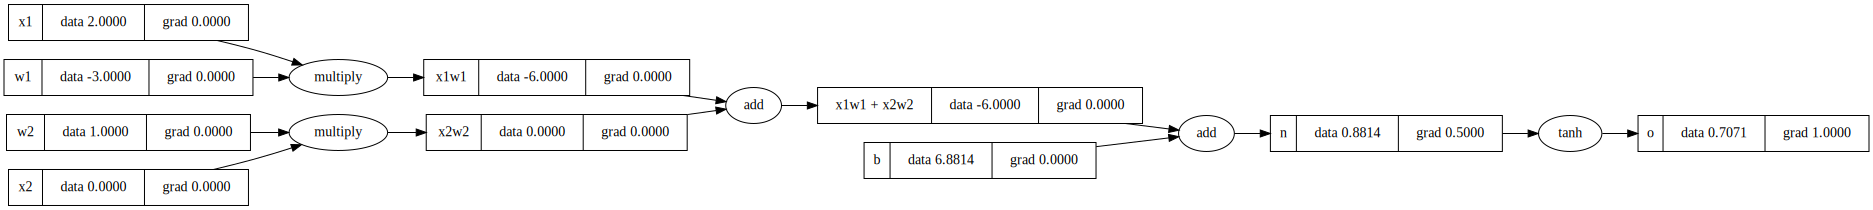

In [112]:
draw_dot(o)

In [113]:
n._backward()

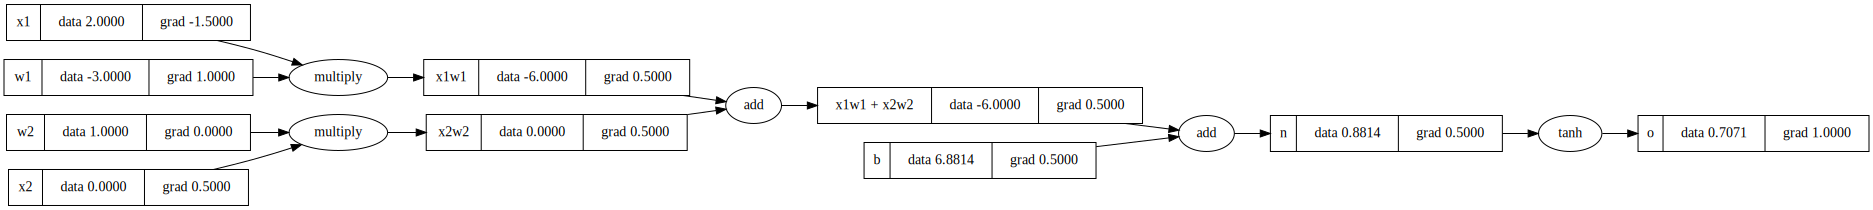

In [121]:
draw_dot(o)

In [117]:
x1w1x2w2._backward()

In [120]:
x1w1._backward()
x2w2._backward()

In [ ]:
o.grad = 1.0

topo = []
visited = set()
def build_topo(v: Value):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)

for node in reversed(topo)

Hey


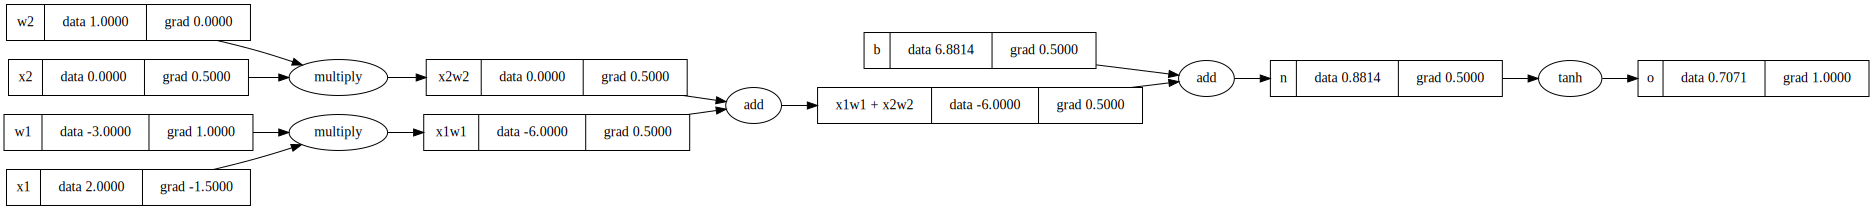

In [130]:
draw_dot(o)

In [124]:
topo

[Value(data=6.881373588701955),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735887019547),
 Value(data=0.7071067820277533)]

In [44]:

# inputs x1,x2

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias
b = Value(6.88137358870195432, label='b')
x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2 +b; n.label='n'
o = n.tanh(); o.label='o'

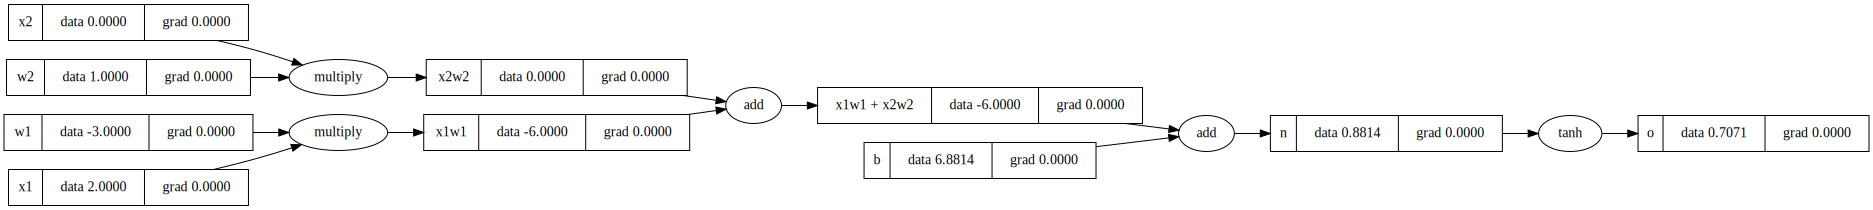

In [45]:
draw_dot(o)

In [46]:
o.backward()

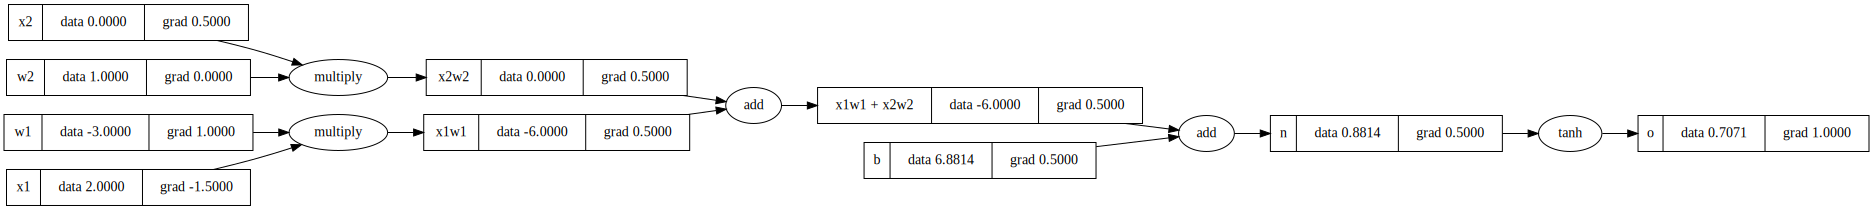

In [47]:
draw_dot(o)

In [41]:
o.backward()

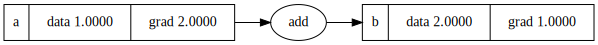

In [150]:
a = Value(1.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)

In [151]:
a + 1

Value(data=2.0)

In [153]:
a*2

Value(data=2.0)

In [19]:
a = Value(2.0, label='a')

In [20]:
a.exp()

Value(data=7.38905609893065)

In [21]:
b = Value(4.0)
a / b

TypeError: unsupported operand type(s) for /: 'Value' and 'Value'